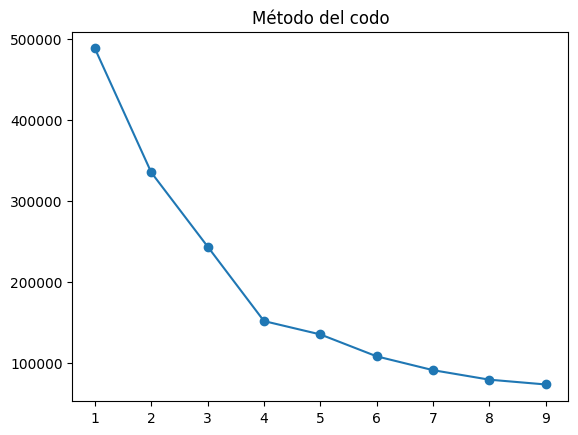

         TOTAL_UNIT_SALES  TOTAL_VALUE_SALES  TOTAL_UNIT_AVG_WEEKLY_SALES  \
CLUSTER                                                                     
0                1.164896          35.567937                     7.217697   
1               39.389067         901.203256                   103.401825   
2                2.415783          82.239587                     7.761363   
3              248.404358        6005.599069                    86.388423   

           REGION  
CLUSTER            
0        1.514653  
1        3.729670  
2        5.076347  
3        6.000000  


In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

fact = pd.read_csv("FACT_SALES.csv")

# Convertir región a numérico
fact["REGION"] = fact["REGION"].astype("category").cat.codes

# Selección de variables
features = fact[[
    "TOTAL_UNIT_SALES",
    "TOTAL_VALUE_SALES",
    "TOTAL_UNIT_AVG_WEEKLY_SALES",
    "REGION"
]]

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# Método del codo
inertia = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.title("Método del codo")
plt.show()

# KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
fact["CLUSTER"] = kmeans.fit_predict(X_scaled)

# Resultados
print(fact.groupby("CLUSTER").mean(numeric_only=True))


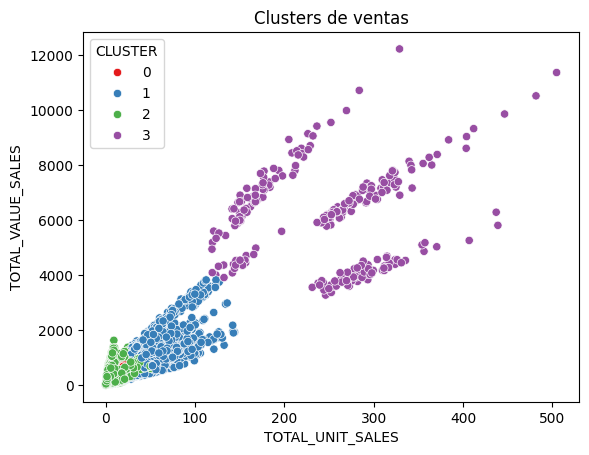

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    x=fact["TOTAL_UNIT_SALES"],
    y=fact["TOTAL_VALUE_SALES"],
    hue=fact["CLUSTER"],
    palette="Set1"
)
plt.title("Clusters de ventas")
plt.show()

In [5]:
cluster_stats = fact.groupby("CLUSTER").agg({
    "TOTAL_UNIT_SALES": ["mean", "median", "std"],
    "TOTAL_VALUE_SALES": ["mean", "median", "std"],
    "REGION": lambda x: x.mode()[0]  # región más frecuente
})
print(cluster_stats)

# Conteo por cluster
print(fact["CLUSTER"].value_counts())

        TOTAL_UNIT_SALES                     TOTAL_VALUE_SALES             \
                    mean   median        std              mean     median   
CLUSTER                                                                     
0               1.164896    0.250   2.602863         35.567937    12.1195   
1              39.389067   36.342  26.670294        901.203256   907.9295   
2               2.415783    0.495   5.237380         82.239587    21.5770   
3             248.404358  260.560  75.022773       6005.599069  6235.9810   

                       REGION  
                 std <lambda>  
CLUSTER                        
0          67.070679        1  
1         661.208956        6  
2         147.910340        6  
3        1737.641443        6  
CLUSTER
0    66608
2    51986
1     3148
3      260
Name: count, dtype: int64


In [6]:
fact.groupby("CLUSTER")[
    ["TOTAL_UNIT_SALES", "TOTAL_VALUE_SALES"]
].mean()

,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES
CLUSTER,,
0,1.164896,35.567937
1,39.389067,901.203256
2,2.415783,82.239587
3,248.404358,6005.599069


In [7]:
fact.groupby(["CLUSTER", "REGION"]).size()

CLUSTER  REGION
0        0         15505
         1         18122
         2         16177
         3         16804
1        0           276
         1           383
         2           319
         3           321
         4           417
         5           503
         6           929
2        3            57
         4         15718
         5         16410
         6         19801
3        6           260
dtype: int64

In [8]:
fact.to_csv("clustering_resultados.csv", index=False)